# ECCO Grid Transformation Demo

This notebook demonstrates how to:
1. Load precomputed sparse matrix mapping factors
2. Load land masks for each depth level
3. Load ECCO native grid geometry (hFacC, XC, YC, etc.)
4. Transform a 3D field (hFacC) from native LLC90 grid to regular lat-lon grid

## Overview

ECCO uses the Lat-Lon-Cap (LLC) grid with complex topology. For most users, we need to transform to a regular lat-lon grid. This is done using precomputed sparse interpolation matrices - one matrix per depth level.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
import lzma
import pickle
from scipy import sparse

import ecco_v4_py as ecco
# Configure plotting
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

## 1. Set up file paths

Adjust these paths to match your local setup:

In [94]:
# Path to mapping factors directory
# Should contain: sparse/, land_mask/, latlon_grid/, 3D/
mapping_factors_dir = Path('/Users/ifenty/tmp/mapping_factors_method_1/')

# Path to native grid geometry NetCDF file
grid_geometry_file = Path('/Users/ifenty/git_repo_others/ECCO-Dataset-Production/demos/data/ecco_grids/V4r5/grid_ECCOV4r5/GRID_GEOMETRY_ECCO_V4r5_native_llc0090.nc')

# Verify paths exist
assert mapping_factors_dir.exists(), f"Mapping factors directory not found: {mapping_factors_dir}"
assert grid_geometry_file.exists(), f"Grid geometry file not found: {grid_geometry_file}"

print(f"✓ Mapping factors directory: {mapping_factors_dir}")
print(f"✓ Grid geometry file: {grid_geometry_file}")

✓ Mapping factors directory: /Users/ifenty/tmp/mapping_factors_method_1
✓ Grid geometry file: /Users/ifenty/git_repo_others/ECCO-Dataset-Production/demos/data/ecco_grids/V4r5/grid_ECCOV4r5/GRID_GEOMETRY_ECCO_V4r5_native_llc0090.nc


## 2. Load native grid geometry

Load the ECCO native grid NetCDF file containing hFacC (3D wet/dry fraction), coordinates, etc.

In [109]:
# Load native grid
native_grid = xr.open_dataset(grid_geometry_file).load()

print("Native grid variables:")
print(native_grid.data_vars)

depth = native_grid.Z

# Extract hFacC (3D field: vertical fraction of open cell)
# hFacC shape is typically (nz, ntile, ny, nx) or similar
hFacC = native_grid['hFacC']

print(f"\nhFacC shape: {hFacC.shape}")
print(f"hFacC range: [{hFacC.min():.3f}, {hFacC.max():.3f}]")
print(f"Non-zero points: {np.count_nonzero(hFacC):,} / {hFacC.size:,}")

Native grid variables:
Data variables:
    CS                      (tile, j, i) float32 421kB 0.06158 ... -0.9984
    SN                      (tile, j, i) float32 421kB -0.9981 ... -0.05718
    rA                      (tile, j, i) float32 421kB 3.623e+08 ... 3.611e+08
    dxG                     (tile, j_g, i) float32 421kB 1.558e+04 ... 2.314e+04
    dyG                     (tile, j, i_g) float32 421kB 2.321e+04 ... 1.558e+04
    Depth                   (tile, j, i) float32 421kB 0.0 0.0 0.0 ... 0.0 0.0
    rAz                     (tile, j_g, i_g) float32 421kB 1.799e+08 ... 3.64...
    dxC                     (tile, j, i_g) float32 421kB 1.558e+04 ... 2.341e+04
    dyC                     (tile, j_g, i) float32 421kB 1.156e+04 ... 1.558e+04
    rAw                     (tile, j, i_g) float32 421kB 3.617e+08 ... 3.648e+08
    rAs                     (tile, j_g, i) float32 421kB 1.802e+08 ... 3.605e+08
    drC                     (k_p1) float32 204B 5.0 10.0 10.0 ... 445.0 228.2
    drF

## 3. Load lat-lon grid definition

The `latlon_grid.xz` file contains the **source of truth** for lat-lon coordinates and bounds.

In [110]:
latlon_grid_file = mapping_factors_dir / 'latlon_grid' / 'latlon_grid.xz'

with lzma.open(latlon_grid_file, 'rb') as f:
    latlon_grid = pickle.load(f)

# latlon_grid = [latlon_bounds, depth_bounds, target_grid_dict, wet_pts_k]
print(f'latlon_grid is a list of length {len(latlon_grid)}')

latlon_bounds = latlon_grid[0]
depth_bounds = latlon_grid[1]
target_grid_dict = latlon_grid[2]
wet_pts_k = latlon_grid[3]

# additional information is in the latlon_grid_area_and_radius file
latlon_grid_area_radius_fname = Path(mapping_factors_dir) / 'latlon_grid_area_and_radius.nc'
latlon_grid_area_radius_DA = xr.open_dataset(latlon_grid_area_radius_fname)
lats = latlon_grid_area_radius_DA.lat
lons = latlon_grid_area_radius_DA.lon


latlon_grid is a list of length 4


In [111]:

# Extract coordinate bounds
latitude_bounds = latlon_bounds['lat']
longitude_bounds = latlon_bounds['lon']

# Calculate cell centers (midpoints of bounds)
latitude = np.mean(latitude_bounds, axis=1)
longitude = np.mean(longitude_bounds, axis=1)

nlat = len(latitude)
nlon = len(longitude)
nz = len(depth)

print(f"\nGrid dimensions:")
print(f"  Latitude: {nlat} points ({latitude.min():.2f}° to {latitude.max():.2f}°)")
print(f"  Longitude: {nlon} points ({longitude.min():.2f}° to {longitude.max():.2f}°)")
print(f"  Depth: {nz} levels ({depth.min():.2f} m to {depth.max():.2f} m)")


Grid dimensions:
  Latitude: 360 points (-89.75° to 89.75°)
  Longitude: 720 points (-179.75° to 179.75°)
  Depth: 50 levels (-5906.25 m to -5.00 m)


## 4. Prepare native grid data for transformation

The sparse matrices expect a 1D array of "wet points" (ocean points with hFacC > 0) for each depth level.

In [156]:
# Get dimensions from hFacC
# Typical shape: (nz, 13, 90, 90) for LLC90 grid with 13 tiles

hFacC = ecco_grid_native.hFacC

nz_native = hFacC.shape[0]

# Flatten spatial dimensions for each depth level
# Keep depth as first dimension, flatten everything else
hFacC_flat = hFacC.values.reshape(nz_native, -1)

print(f"HFacC")
print(f"  Depth levels: {hFacC_flat.shape[0]}")
print(f"  Horizontal points: {len(hFacC[0].values.ravel())}")

# For each depth level, we only use "wet" points (hFacC > 0)

native_wet_point_indices = {}
for k in range(nz_native):
    native_wet_point_indices[k] = \
        np.where(ecco_grid_native['hFacC'][k,:]>0)
    
   
    if k < 3 or k == nz_native - 1:
        print(f"     Level {k:2d}: {len(native_wet_point_indices[k][0]):10,} wet points")

HFacC
  Depth levels: 50
  Horizontal points: 105300
     Level  0:     60,570 wet points
     Level  1:     60,570 wet points
     Level  2:     59,815 wet points
     Level 49:        818 wet points


(<Figure size 900x900 with 25 Axes>,
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]))

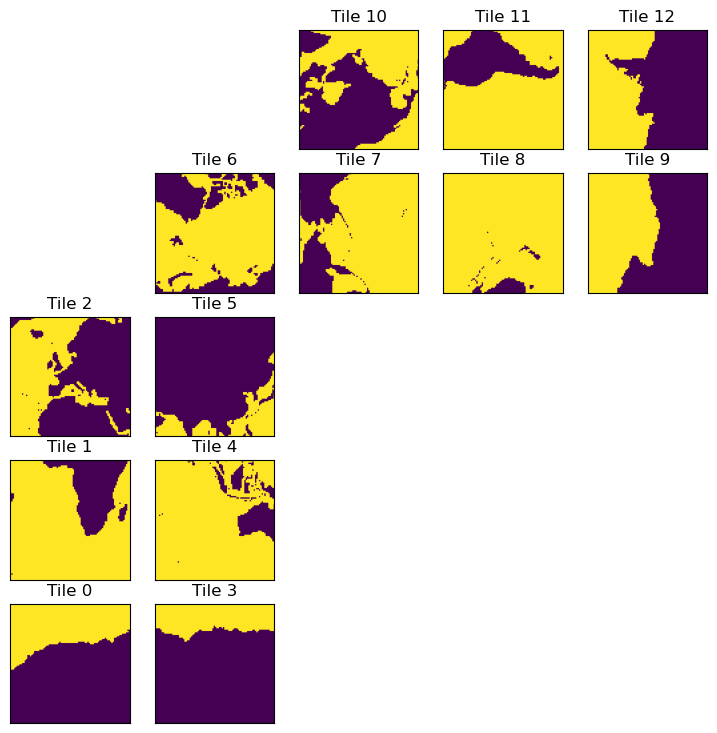

In [157]:
X = np.zeros([13, 90, 90])
X[native_wet_point_indices[0]]= 1
ecco.plot_tiles(X)

## 5. Load sparse matrices and land masks

For each depth level, we have:
- A sparse interpolation matrix (CSR format in `.npz` files)
- A land mask (LZMA-compressed pickle in `.xz` files)

In [57]:
sparse_dir = mapping_factors_dir / 'sparse'
land_mask_dir = mapping_factors_dir / 'land_mask'

# Check how many levels are available
sparse_files = sorted(sparse_dir.glob('sparse_matrix_*.npz'))
land_mask_files = sorted(land_mask_dir.glob('ecco_latlon_land_mask_*.xz'))

print(f"Found {len(sparse_files)} sparse matrix files")
print(f"Found {len(land_mask_files)} land mask files")

# Load all sparse matrices
sparse_matrices = []
for k in range(min(nz, len(sparse_files))):
    sparse_file = sparse_dir / f'sparse_matrix_{k}.npz'
    if sparse_file.exists():
        sparse_matrix = sparse.load_npz(sparse_file)
        sparse_matrices.append(sparse_matrix)
        
        if k < 3:
            print(f"  Level {k:2d}: sparse matrix shape {sparse_matrix.shape}, "
                  f"{sparse_matrix.nnz:,} non-zero entries")
    else:
        print(f"  WARNING: Missing sparse_matrix_{k}.npz")
        break

print(f"\nLoaded {len(sparse_matrices)} sparse matrices")

# Load all land masks
land_masks = []
for k in range(min(nz, len(land_mask_files))):
    land_mask_file = land_mask_dir / f'ecco_latlon_land_mask_{k}.xz'
    if land_mask_file.exists():
        with lzma.open(land_mask_file, 'rb') as f:
            land_mask = pickle.load(f)
        land_masks.append(land_mask)
        
        if k < 3:
            ocean_points = np.sum(~np.isnan(land_mask))
            print(f"  Level {k:2d}: land mask shape {land_mask.shape}, "
                  f"{ocean_points:,} ocean points")
    else:
        print(f"  WARNING: Missing ecco_latlon_land_mask_{k}.xz")
        break

print(f"\nLoaded {len(land_masks)} land masks")

Found 50 sparse matrix files
Found 50 land mask files
  Level  0: sparse matrix shape (60570, 259200), 169,116 non-zero entries
  Level  1: sparse matrix shape (60570, 259200), 169,116 non-zero entries
  Level  2: sparse matrix shape (59815, 259200), 167,299 non-zero entries

Loaded 50 sparse matrices
  Level  0: land mask shape (259200,), 169,058 ocean points
  Level  1: land mask shape (259200,), 169,058 ocean points
  Level  2: land mask shape (259200,), 167,244 ocean points

Loaded 50 land masks


## 6. Transform native grid to lat-lon grid

For each depth level:
1. Extract wet points from native grid
2. Apply sparse matrix transformation
3. Reshape to 2D lat-lon grid
4. Apply land mask (set land points to NaN)

In [158]:
ecco_grid_native.data_vars

Data variables:
    CS                      (tile, j, i) float32 421kB 0.06158 ... -0.9984
    SN                      (tile, j, i) float32 421kB -0.9981 ... -0.05718
    rA                      (tile, j, i) float32 421kB 3.623e+08 ... 3.611e+08
    dxG                     (tile, j_g, i) float32 421kB 1.558e+04 ... 2.314e+04
    dyG                     (tile, j, i_g) float32 421kB 2.321e+04 ... 1.558e+04
    Depth                   (tile, j, i) float32 421kB 0.0 0.0 0.0 ... 0.0 0.0
    rAz                     (tile, j_g, i_g) float32 421kB 1.799e+08 ... 3.64...
    dxC                     (tile, j, i_g) float32 421kB 1.558e+04 ... 2.341e+04
    dyC                     (tile, j_g, i) float32 421kB 1.156e+04 ... 1.558e+04
    rAw                     (tile, j, i_g) float32 421kB 3.617e+08 ... 3.648e+08
    rAs                     (tile, j_g, i) float32 421kB 1.802e+08 ... 3.605e+08
    drC                     (k_p1) float32 204B 5.0 10.0 10.0 ... 445.0 228.2
    drF                     (k

In [178]:
# example 2D mapping
def map_2D_native_to_latlon(tmp_0, k):
        
    # extract 
    tmp_0_wet = tmp_0.values[native_wet_point_indices[0]]
    
    print(f'lengths of the 2D field {len(tmp_0.values.ravel())} and # of wet points {len(tmp_0_wet.ravel())}')
    
    # do the mapping, result is 1D
    tmp_0_wet_ll_1D = sparse_matrices[0].T.dot(tmp_0_wet)
    # reshape mapped field to 2D lat-lon
    tmp_0_wet_ll_2D = np.reshape(tmp_0_wet_ll_1D, [nlat, nlon])
    
    # apply land mask to 1D form of mapped field
    tmp_0_wet_ll_1D_masked = np.where(np.isnan(land_masks[0]), np.nan, tmp_0_wet_ll_1D)
    # reshape 1D land-masked field to 2D lat-lon
    tmp_0_wet_ll_2D_masked = np.reshape(tmp_0_wet_ll_1D_masked, [nlat, nlon])

    return tmp_0_wet_ll_2D, tmp_0_wet_ll_2D_masked


In [211]:
nk=50
all_mask_fnames = [f'ecco_latlon_land_mask_{i}.xz' for i in range(nk)]
all_mask_fnames += ['ecco_latlon_land_mask_all_wet_in_column']
all_mask_fnames

['ecco_latlon_land_mask_0.xz',
 'ecco_latlon_land_mask_1.xz',
 'ecco_latlon_land_mask_2.xz',
 'ecco_latlon_land_mask_3.xz',
 'ecco_latlon_land_mask_4.xz',
 'ecco_latlon_land_mask_5.xz',
 'ecco_latlon_land_mask_6.xz',
 'ecco_latlon_land_mask_7.xz',
 'ecco_latlon_land_mask_8.xz',
 'ecco_latlon_land_mask_9.xz',
 'ecco_latlon_land_mask_10.xz',
 'ecco_latlon_land_mask_11.xz',
 'ecco_latlon_land_mask_12.xz',
 'ecco_latlon_land_mask_13.xz',
 'ecco_latlon_land_mask_14.xz',
 'ecco_latlon_land_mask_15.xz',
 'ecco_latlon_land_mask_16.xz',
 'ecco_latlon_land_mask_17.xz',
 'ecco_latlon_land_mask_18.xz',
 'ecco_latlon_land_mask_19.xz',
 'ecco_latlon_land_mask_20.xz',
 'ecco_latlon_land_mask_21.xz',
 'ecco_latlon_land_mask_22.xz',
 'ecco_latlon_land_mask_23.xz',
 'ecco_latlon_land_mask_24.xz',
 'ecco_latlon_land_mask_25.xz',
 'ecco_latlon_land_mask_26.xz',
 'ecco_latlon_land_mask_27.xz',
 'ecco_latlon_land_mask_28.xz',
 'ecco_latlon_land_mask_29.xz',
 'ecco_latlon_land_mask_30.xz',
 'ecco_latlon_land

(<Figure size 900x900 with 25 Axes>,
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]))

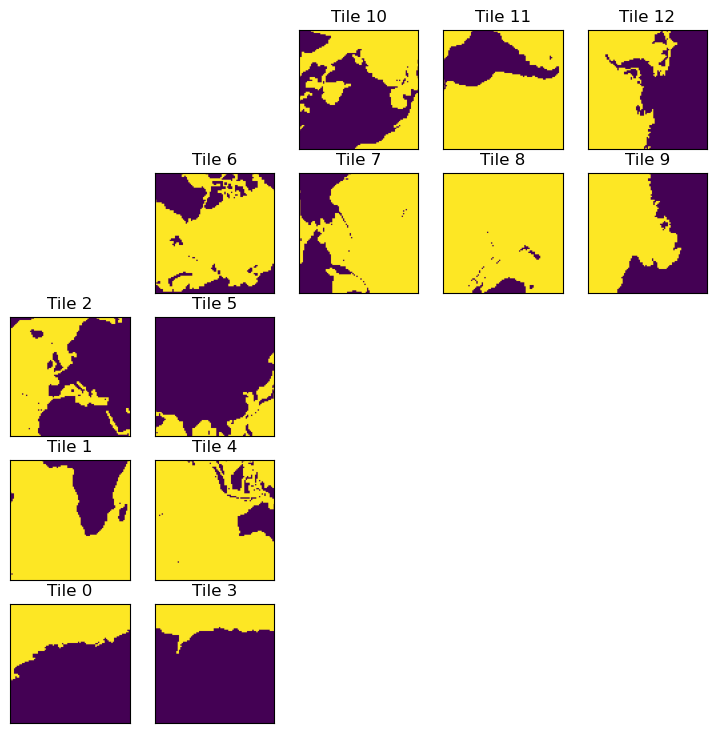

In [215]:
source_field_pre = np.where(np.sum(np.where(ecco_grid_native.maskC ==True, 1, 0),axis=0) > 0, 1, 0)
ecco.plot_tiles(source_field_pre)

In [216]:
source_field = np.where(np.sum(np.where(ecco_grid_native.maskC ==True, 1, 0),axis=0) > 0, 1, 0).ravel()
source_field

array([0, 0, 0, ..., 0, 0, 0])

In [199]:
for i in range(-1,0):
    print(i)

-1


lengths of the 2D field 105300 and # of wet points 60570


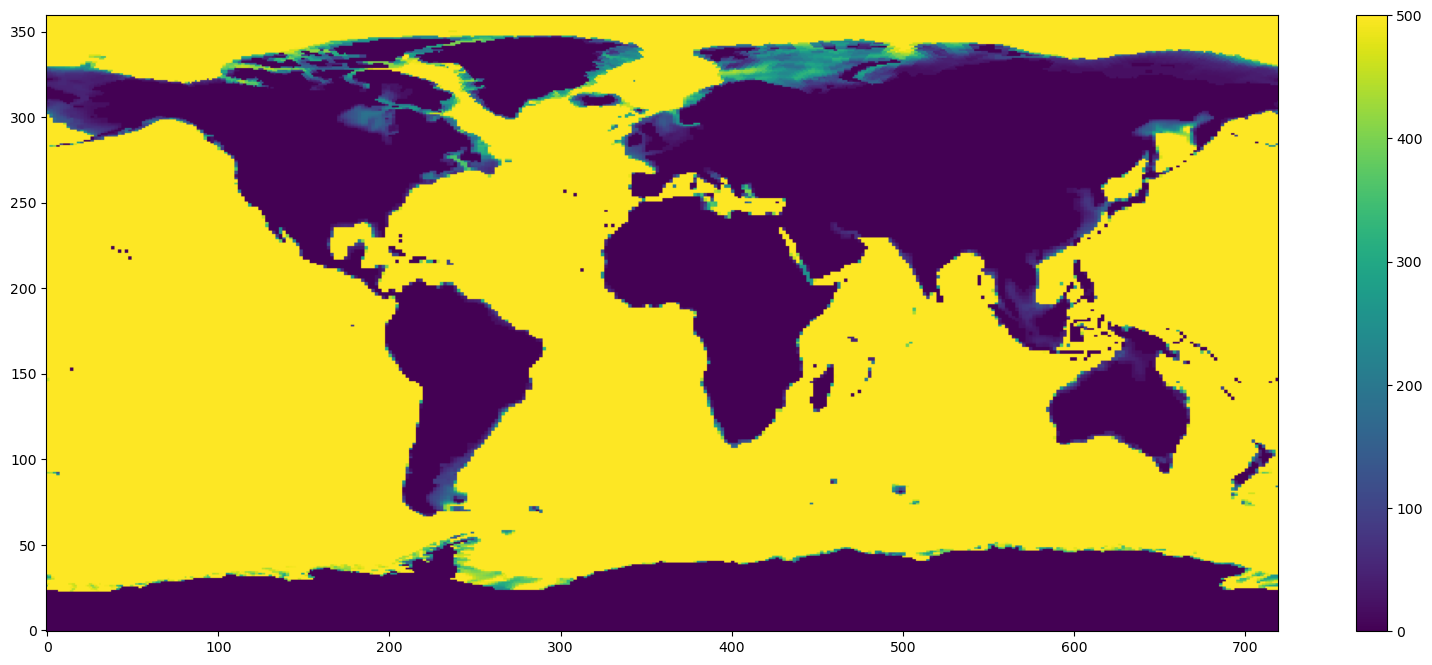

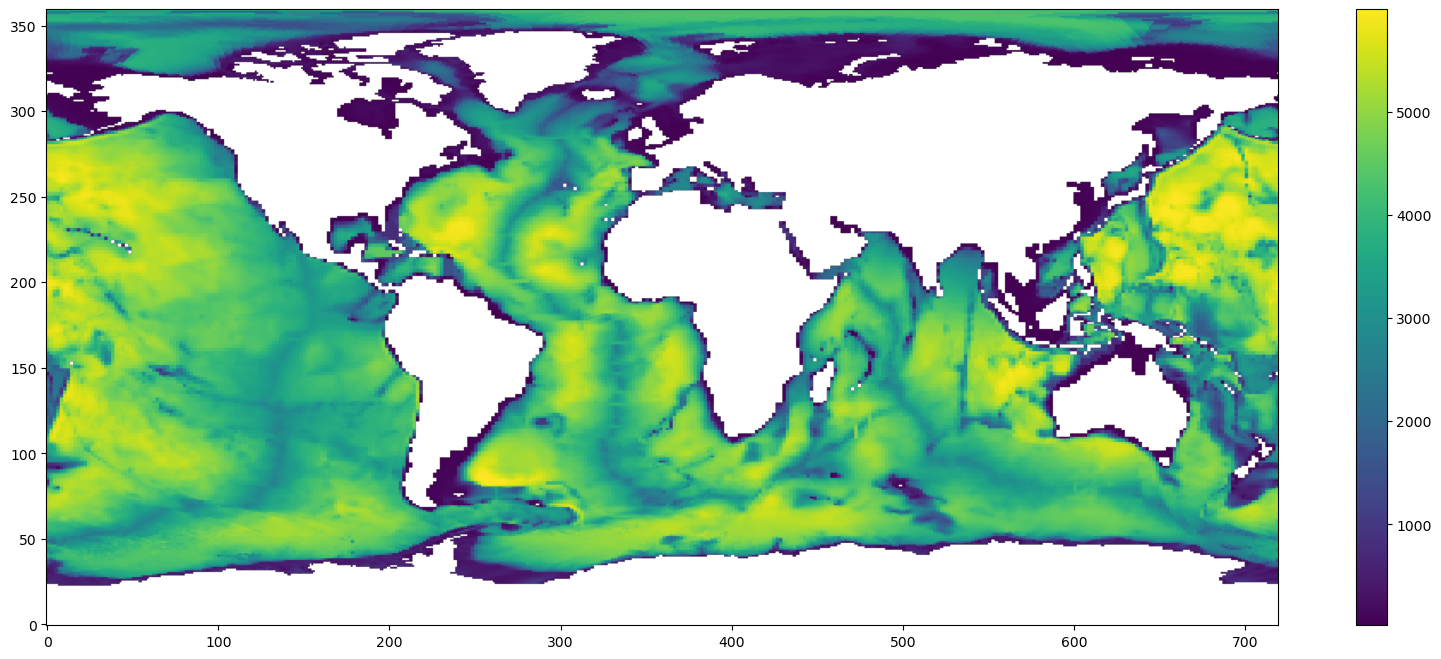

In [190]:

# select 2D field
tmp_0 = ecco_grid_native.ocean_column_thickness
# plot the original 2D

tmp_0_wet_ll_2D, tmp_0_wet_ll_2D_masked = map_2D_native_to_latlon(tmp_0, 0)
f1=10;f2=4
s=2;
sf1 = f1*s; sf2=f2*s;
plt.figure(figsize=[sf1,sf2])
plt.imshow(tmp_0_wet_ll_2D, origin='lower', vmin=0, vmax=500); plt.colorbar();
plt.figure(figsize=[sf1,sf2])
# and land-masked 2D
plt.imshow(tmp_0_wet_ll_2D_masked, origin='lower');plt.colorbar();



In [98]:
# Initialize output array
hFacC_latlon = np.full((len(sparse_matrices), nlat, nlon), np.nan)

print('The 3D native grid variable will transformed to a lat-lon grid with dimension')
print(hFacC_latlon.shape)

print("Transforming native grid to lat-lon grid...\n")

for k in range(len(sparse_matrices)):
    # Get wet points for this level
    wet_values = wet_values_per_level[k]

    var = hFacC[0].data.squeeze()
    
    # Apply sparse matrix transformation
    # sparse_matrix shape: (nlat*nlon, n_wet_native)
    # wet_values shape: (n_wet_native,)
    # Result shape: (nlat*nlon,)
    transformed_flat = sparse_matrices[k].dot(wet_values)
    
    # Reshape to 2D lat-lon grid
    transformed_2d = transformed_flat.reshape(nlat, nlon)
    
    # Apply land mask
    transformed_2d = transformed_2d * land_masks[k]
    
    # Store result
    hFacC_latlon[k, :, :] = transformed_2d
    
    if k < 3 or k == len(sparse_matrices) - 1:
        valid_points = np.sum(~np.isnan(transformed_2d))
        if valid_points > 0:
            mean_val = np.nanmean(transformed_2d)
            print(f"  Level {k:2d}: {valid_points:5,} valid points, "
                  f"mean hFacC = {mean_val:.3f}")

print(f"\n✓ Transformation complete!")
print(f"  Output shape: {hFacC_latlon.shape} (depth, lat, lon)")
print(f"  Total valid points: {np.sum(~np.isnan(hFacC_latlon)):,}")

The 3D native grid variable will transformed to a lat-lon grid with dimension
(50, 360, 720)
Transforming native grid to lat-lon grid...



AttributeError: 'memoryview' object has no attribute 'squeeze'

## 7. Create xarray Dataset for easy manipulation

In [ ]:
# Create xarray Dataset
ds_latlon = xr.Dataset(
    data_vars={
        'hFacC': (['Z', 'latitude', 'longitude'], hFacC_latlon),
    },
    coords={
        'Z': depth[:len(sparse_matrices)],
        'latitude': latitude,
        'longitude': longitude,
    },
    attrs={
        'title': 'ECCO hFacC transformed to lat-lon grid',
        'description': 'Vertical fraction of open cell, interpolated from native LLC90 grid',
    }
)

# Add attributes
ds_latlon['hFacC'].attrs = {
    'long_name': 'Vertical fraction of open cell',
    'units': '1',
    'valid_range': [0.0, 1.0],
}

ds_latlon['Z'].attrs = {
    'long_name': 'Depth',
    'units': 'm',
    'positive': 'down',
}

print(ds_latlon)

## 8. Visualize the results

### 8.1 Surface level (k=0)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), 
                         subplot_kw={'projection': ccrs.PlateCarree()})

# Plot surface hFacC
ax = axes[0]
data = ds_latlon['hFacC'].isel(Z=0)
im = ax.pcolormesh(ds_latlon.longitude, ds_latlon.latitude, data,
                   transform=ccrs.PlateCarree(),
                   vmin=0, vmax=1, cmap='Blues')
ax.add_feature(cfeature.LAND, color='lightgray')
ax.coastlines(resolution='110m', linewidth=0.5)
ax.set_title(f'Surface hFacC (k=0, depth={ds_latlon.Z[0].values:.1f} m)', fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.colorbar(im, ax=ax, label='hFacC', shrink=0.8)

# Plot a deeper level
ax = axes[1]
k_deep = min(10, len(sparse_matrices) - 1)
data = ds_latlon['hFacC'].isel(Z=k_deep)
im = ax.pcolormesh(ds_latlon.longitude, ds_latlon.latitude, data,
                   transform=ccrs.PlateCarree(),
                   vmin=0, vmax=1, cmap='Blues')
ax.add_feature(cfeature.LAND, color='lightgray')
ax.coastlines(resolution='110m', linewidth=0.5)
ax.set_title(f'hFacC at k={k_deep} (depth={ds_latlon.Z[k_deep].values:.1f} m)', fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.colorbar(im, ax=ax, label='hFacC', shrink=0.8)

plt.tight_layout()
plt.show()

### 8.2 Vertical profile at a specific location

In [ ]:
# Select a location (e.g., Pacific Ocean)
lon_point = -140.0
lat_point = 30.0

# Find nearest grid point
i_lon = np.argmin(np.abs(ds_latlon.longitude.values - lon_point))
i_lat = np.argmin(np.abs(ds_latlon.latitude.values - lat_point))

actual_lon = ds_latlon.longitude.values[i_lon]
actual_lat = ds_latlon.latitude.values[i_lat]

# Extract vertical profile
hFacC_profile = ds_latlon['hFacC'].isel(longitude=i_lon, latitude=i_lat)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.plot(hFacC_profile.values, -ds_latlon.Z.values, 'o-', linewidth=2, markersize=4)
ax.set_xlabel('hFacC (fraction)', fontsize=12)
ax.set_ylabel('Depth (m)', fontsize=12)
ax.set_title(f'Vertical profile of hFacC at ({actual_lat:.2f}°N, {actual_lon:.2f}°E)', 
             fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1.05])
plt.tight_layout()
plt.show()

### 8.3 Zonal mean (averaged over longitude)

In [ ]:
# Calculate zonal mean
hFacC_zonal = ds_latlon['hFacC'].mean(dim='longitude')

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
im = ax.contourf(ds_latlon.latitude, -ds_latlon.Z, hFacC_zonal.values,
                 levels=np.linspace(0, 1, 21), cmap='Blues', extend='neither')
ax.set_xlabel('Latitude (°N)', fontsize=12)
ax.set_ylabel('Depth (m)', fontsize=12)
ax.set_title('Zonal mean hFacC (averaged over longitude)', fontsize=13, fontweight='bold')
ax.set_ylim([-6000, 0])
plt.colorbar(im, ax=ax, label='hFacC', shrink=0.8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8.4 Ocean basin coverage at different depths

In [ ]:
# Select 4 depth levels to compare
depths_to_plot = [0, 5, 15, 30]
depths_to_plot = [d for d in depths_to_plot if d < len(sparse_matrices)]

fig, axes = plt.subplots(2, 2, figsize=(16, 12),
                        subplot_kw={'projection': ccrs.Robinson()})
axes = axes.flatten()

for idx, k in enumerate(depths_to_plot):
    ax = axes[idx]
    data = ds_latlon['hFacC'].isel(Z=k)
    depth_val = ds_latlon.Z[k].values
    
    im = ax.pcolormesh(ds_latlon.longitude, ds_latlon.latitude, data,
                      transform=ccrs.PlateCarree(),
                      vmin=0, vmax=1, cmap='Blues')
    ax.add_feature(cfeature.LAND, color='lightgray', zorder=1)
    ax.coastlines(resolution='110m', linewidth=0.5, zorder=2)
    ax.set_title(f'Depth level k={k} ({depth_val:.1f} m)', fontsize=11, fontweight='bold')
    
    # Calculate coverage
    ocean_coverage = np.sum(~np.isnan(data.values)) / (nlat * nlon) * 100
    ax.text(0.02, 0.02, f'Ocean coverage: {ocean_coverage:.1f}%',
           transform=ax.transAxes, fontsize=9,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.colorbar(im, ax=axes, label='hFacC', shrink=0.6, pad=0.02)
plt.suptitle('hFacC at different depth levels', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 9. Summary statistics

In [ ]:
print("="*70)
print("TRANSFORMATION SUMMARY")
print("="*70)

print(f"\nInput (Native Grid):")
print(f"  Shape: {hFacC.shape}")
print(f"  Total points: {hFacC.size:,}")
print(f"  Wet points: {np.count_nonzero(hFacC):,}")

print(f"\nOutput (Lat-Lon Grid):")
print(f"  Shape: {hFacC_latlon.shape}")
print(f"  Total points: {hFacC_latlon.size:,}")
print(f"  Ocean points: {np.sum(~np.isnan(hFacC_latlon)):,}")

print(f"\nDepth-level statistics:")
for k in range(min(5, len(sparse_matrices))):
    data = hFacC_latlon[k, :, :]
    ocean_pts = np.sum(~np.isnan(data))
    mean_val = np.nanmean(data)
    print(f"  Level {k:2d} (depth={ds_latlon.Z[k].values:7.1f} m): "
          f"{ocean_pts:5,} ocean points, mean hFacC = {mean_val:.4f}")

print("\n" + "="*70)
print("✓ Demo complete!")
print("="*70)

## 10. Optional: Save transformed data to NetCDF

In [ ]:
# Uncomment to save:
# output_file = 'hFacC_latlon_demo.nc'
# ds_latlon.to_netcdf(output_file)
# print(f"Saved to {output_file}")

## Notes

### How the transformation works:

1. **Native grid → 1D wet points**: For each depth level, flatten the native grid and extract only ocean points (hFacC > 0)

2. **Sparse matrix multiplication**: The sparse matrix has shape `(nlat×nlon, n_wet_native)`. When multiplied by the 1D array of wet point values, it produces a 1D array of length `nlat×nlon`

3. **Reshape to 2D**: Reshape the 1D result back to `(nlat, nlon)` grid

4. **Apply land mask**: Multiply by the land mask to set land points to NaN

### Key files:

- `sparse/sparse_matrix_k.npz`: Sparse interpolation matrix for depth level k (scipy CSR format)
- `land_mask/ecco_latlon_land_mask_k.xz`: Land mask for depth level k (LZMA-compressed pickle)
- `latlon_grid/latlon_grid.xz`: Lat-lon coordinate bounds (source of truth)

### Performance notes:

- Sparse matrix multiplication is very efficient (only computes for wet points)
- Loading `.xz` files has some overhead, but keeps file sizes small
- For production, the `ECCOMappingFactors` class caches these for reuse across multiple variables

### Related code:

- `src/ecco_dataset_production/ecco_mapping_factors.py`: `ECCOMappingFactors` class
- `src/ecco_dataset_production/ecco_dataset.py`: `ECCOMDSDataset.as_latlon()` method
- `src/ecco_dataset_production/apps/create_factors.py`: Generates these mapping factors